# 14. MovieLens İşbirlikçi Film Önerisi

**Kategori:** Öneri Sistemleri  
**Gerçek veri seti:** GroupLens MovieLens latest-small  
**Veri kaynağı:** [https://grouplens.org/datasets/movielens/latest/](https://grouplens.org/datasets/movielens/latest/)  
**Amaç:** Kullanıcı puanlama örüntülerinden filme benzer filmler bulmak.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Puan verisi EDA'sı

Puan: 100836 | Kullanıcı: 610 | Film: 9724


,count,mean,std,min,25%,50%,75%,max
rating,100836.0,3.501557,1.042529,0.5,3.0,3.5,4.0,5.0


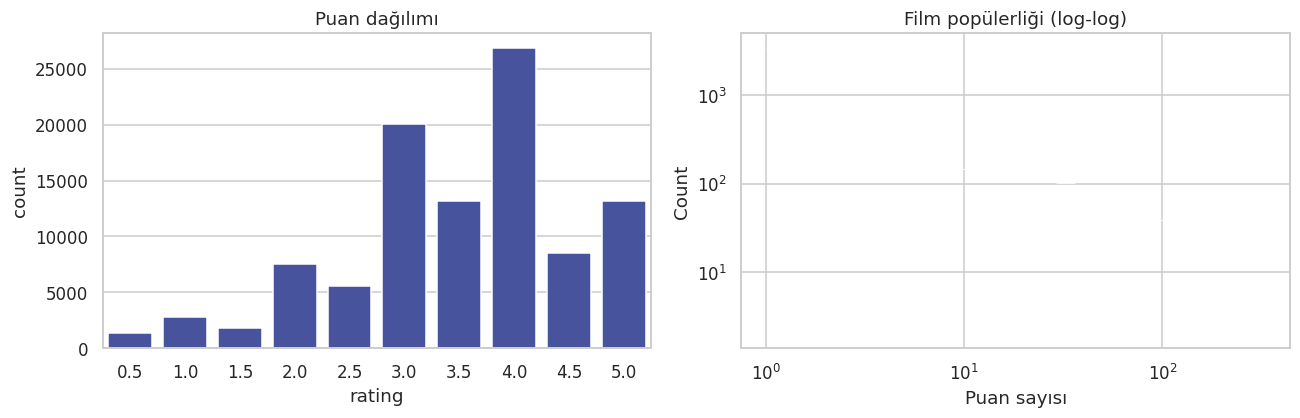

In [2]:
ratings = pd.read_csv(DATA_DIR / "movielens_ratings.csv")
movies = pd.read_csv(DATA_DIR / "movielens_movies.csv")
print("Puan:", len(ratings), "| Kullanıcı:", ratings.userId.nunique(), "| Film:", ratings.movieId.nunique())
display(ratings.rating.describe().to_frame().T)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=ratings, x="rating", color="#3949AB", ax=axes[0])
axes[0].set(title="Puan dağılımı")
popularity = ratings.groupby("movieId").size()
sns.histplot(popularity, bins=50, log_scale=(True, True), ax=axes[1])
axes[1].set(title="Film popülerliği (log-log)", xlabel="Puan sayısı")
plt.tight_layout(); plt.show()

## 2. Film–kullanıcı matrisi ve kosinüs komşuları

In [3]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

popular_ids = popularity[popularity >= 30].index
filtered = ratings[ratings.movieId.isin(popular_ids)]
pivot = filtered.pivot_table(index="movieId", columns="userId", values="rating", fill_value=0)
matrix = csr_matrix(pivot.values)
model = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=11).fit(matrix)
title_map = movies.set_index("movieId").title

def similar_movies(title, n=5):
    movie_id = movies.loc[movies.title.eq(title), "movieId"].iloc[0]
    row = pivot.index.get_loc(movie_id)
    distances, indices = model.kneighbors(matrix[row], n_neighbors=n + 1)
    ids = pivot.index[indices[0][1:]]
    return pd.DataFrame({"title": title_map.loc[ids].values,
                         "similarity": (1 - distances[0][1:]).round(3)})

example_title = "Toy Story (1995)"
display(similar_movies(example_title))

,title,similarity
0,Toy Story 2 (1999),0.573
1,Jurassic Park (1993),0.566
2,Independence Day (a.k.a. ID4) (1996),0.564
3,Star Wars: Episode IV - A New Hope (1977),0.557
4,Forrest Gump (1994),0.547


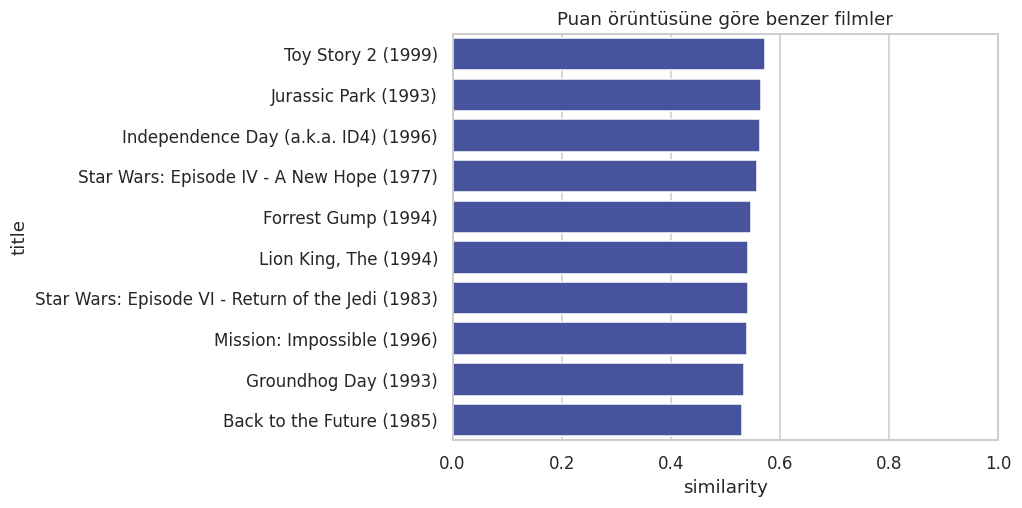

In [4]:
example = similar_movies(example_title, 10)
sns.barplot(data=example, x="similarity", y="title", color="#3949AB")
plt.xlim(0, 1); plt.title("Puan örüntüsüne göre benzer filmler"); plt.show()
joblib.dump({"model": model, "matrix": matrix, "movie_ids": pivot.index.to_numpy(),
             "title_map": title_map, "minimum_ratings": 30},
            MODEL_DIR / "14_movielens_isbirlikci.joblib")
json.dump({"ratings": int(len(ratings)), "users": int(ratings.userId.nunique()),
           "model_movies": int(len(pivot))},
          open(RESULT_DIR / "14_movielens_isbirlikci.json", "w"), indent=2)

## Sonuç

İçerik projesinden farklı olarak tür bilgisi kullanılmadı; kullanıcıların gerçek puan örüntüleri
karşılaştırıldı. Çok az puan alan filmler gürültüyü azaltmak için 30 puan eşiğiyle filtrelendi.
Bu yaklaşım yeni kullanıcı/film soğuk başlangıç sorununa sahiptir.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **puan matrisinden işbirlikçi öneri** biçimindedir.
Bu notebookta **100.836 gerçek puan, sparsity/popülerlik EDA'sı, seyrek matris ve soğuk başlangıç analizi** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).